In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [1]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [3]:
# Define the directory path
directory = "cluster/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'cluster/' have been cleared.


## Load the data

In [ ]:
## Load Distance Restraubt Data 
dist_path = f"traj_data/dis_state0.pkl"
dist = Data.load(dist_path)
dist = dist.array_list
print(f'dist.shape:{np.array(dist).shape}')

## Load Backbone Phi Omega angle 
omega_path = f"traj_data/omegas_state0.pkl"
omegas = Data.load(omega_path)
omegas = omegas.array_list
print(f'omegas.shape: {np.array(omegas).shape}')

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omegas[:, angle_indices] = (omegas[:, angle_indices] + 90.0) % 360.0 - 90.0

feat_all = np.hstack([dist,omegas])
print('feat_all.shape', feat_all.shape)

dist.shape:(100005, 90)
omegas.shape: (100005, 24)
feat_all.shape (100005, 114)


## Filtered Data

In [6]:
residues_to_plot = np.arange(0, 24, 4).tolist()  # [0, 4, 8, 12, 16, 20]
omega_features = feat_all[:, -24:]              # Get the last 24 columns
selected_omegas = omega_features[:, residues_to_plot]

# Apply the condition
mask = (
    (selected_omegas[:, 0] > 90) &
    (selected_omegas[:, 1] < 90) &
    (selected_omegas[:, 2] < 90) &
    (selected_omegas[:, 3] < 90) &
    (selected_omegas[:, 4] > 90) &
    (selected_omegas[:, 5] < 90)
)

In [20]:
filtered_indices = np.where(mask)[0]  # these are indices into feat_all
filtered_omega_feat = feat_all[filtered_indices]
filtered_omega_feat.shape
filtered_indices.shape

(67218,)

## TICA

In [10]:
from deeptime.decomposition import TICA
tica = TICA(lagtime=1, dim=2) # create a tica estimator 

In [11]:
data = filtered_omega_feat
# Fit the tica estimator on data > feat_all 
tica.fit(data)

TICA-6868753936:[{'dim': 2,
                 'epsilon': 1e-06,
                 'lagtime': 1,
                 'observable_transform': <deeptime.basis._monomials.Identity object at 0x1975dd840>,
                 'scaling': 'kinetic_map',
                 'var_cutoff': None}]

In [23]:
# obtain model 
model = tica.fetch_model()
# Create the projection data 
projection = model.transform(data)
print(projection.shape)

(67218, 2)


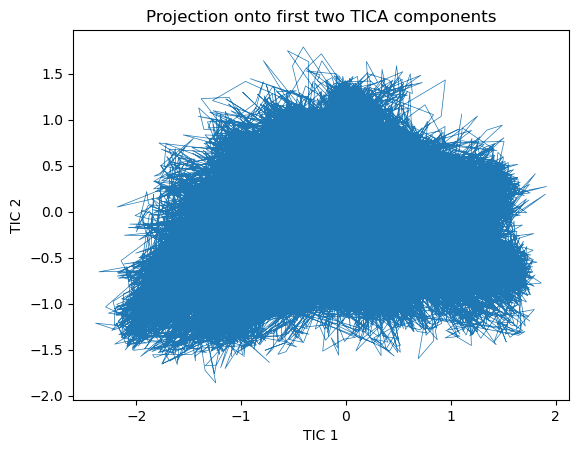

In [24]:
plt.plot(projection[:, 0], projection[:, 1], lw=0.5)
plt.xlabel('TIC 1')
plt.ylabel('TIC 2')
plt.title('Projection onto first two TICA components')
plt.show()

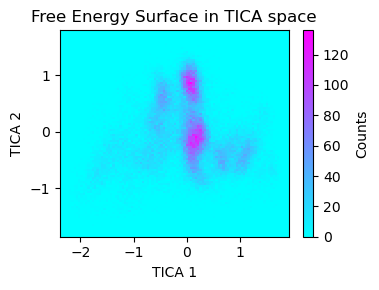

In [25]:

x = projection[:, 0]
y = projection[:, 1]

plt.figure(figsize=(4, 3))
plt.hist2d(x, y, bins=100, cmap='cool')
plt.colorbar(label='Counts')
plt.xlabel('TICA 1')
plt.ylabel('TICA 2')
plt.title('Free Energy Surface in TICA space')
plt.tight_layout()
plt.show()


## Clustering

In [26]:
from deeptime.clustering import MiniBatchKMeans

n_clusters = 10
estimator = KMeans(
    n_clusters=n_clusters,  # number of cluster centers
    max_iter=100,  # maximum number of passes over full dataset when calling fit()
    init_strategy='kmeans++',  # initialization strategy
    fixed_seed=42,
    n_jobs=1
)

In [27]:
clustering_tica = estimator.fit(projection).fetch_model()
assignments = clustering_tica.transform(projection)
#print(np.unique(assignments)) # Print assignment labels 

# Find the cluster centers
cluster_centers = clustering_tica.cluster_centers

In [28]:
## Calcuate the percentage of each assignments 

# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

for label, frequency in sorted_counts.items():    
    precentage = (frequency / total_counts) * 100 
    cluster.append(precentage)
    print(f"Assignment {label}: {frequency}, {precentage:.4g}%")


top_n = 10 # Select number of most populated frame 
# Sort clusters by frequency in descending order
top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")

Assignment 0: 12979, 19.31%
Assignment 1: 7471, 11.11%
Assignment 2: 2987, 4.444%
Assignment 3: 7117, 10.59%
Assignment 4: 7324, 10.9%
Assignment 5: 3067, 4.563%
Assignment 6: 5948, 8.849%
Assignment 7: 3815, 5.676%
Assignment 8: 10599, 15.77%
Assignment 9: 5911, 8.794%
Top 10 most populated clusters:
Assignment 0: 12979 frames, 19.31%
Assignment 8: 10599 frames, 15.77%
Assignment 1: 7471 frames, 11.11%
Assignment 4: 7324 frames, 10.9%
Assignment 3: 7117 frames, 10.59%
Assignment 6: 5948 frames, 8.849%
Assignment 9: 5911 frames, 8.794%
Assignment 7: 3815 frames, 5.676%
Assignment 5: 3067 frames, 4.563%
Assignment 2: 2987 frames, 4.444%


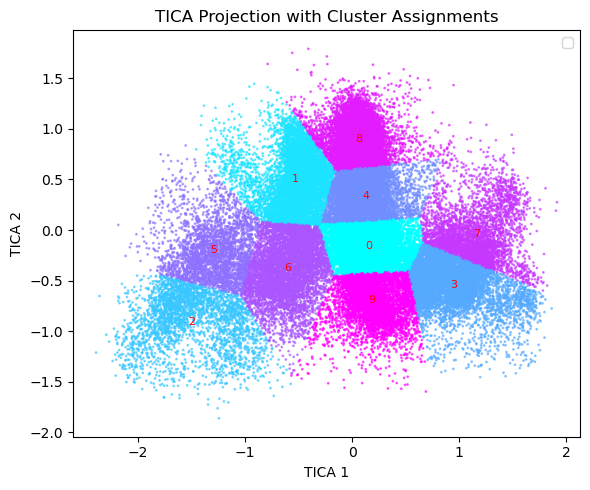

In [29]:
plt.figure(figsize=(6, 5))

# Scatter plot of projection colored by cluster
plt.scatter(projection[:, 0], projection[:, 1], c=assignments, cmap='cool', s=1, alpha=0.6)

# Cluster centers
#plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], color='red', marker='x', s=100, label='Centers')

# Plain number labels at each cluster center
for i, (x, y) in enumerate(cluster_centers):
    plt.text(x, y, str(i), fontsize=8, color='red', ha='center', va='center')

plt.legend()
plt.xlabel("TICA 1")
plt.ylabel("TICA 2")
plt.title("TICA Projection with Cluster Assignments")
plt.tight_layout()
plt.show()


## Analysis the Top Populated Clusters

In [30]:
top_labels = [label for label, _ in top]

top_cluster_data = {}

for label in top_labels:
    indices = np.where(assignments == label)[0]  # Indices in filtered_omega_feat
    original_frame_ids = filtered_indices[indices]  # Map back to feat_all

    top_cluster_data[label] = original_frame_ids
    print(f"Cluster {label}: original frame indices: {original_frame_ids[:5]} ...")



Cluster 0: original frame indices: [ 957  960 1011 1054 1068] ...
Cluster 8: original frame indices: [5688 5740 6968 7009 7034] ...
Cluster 1: original frame indices: [ 876  990  991 1005 1034] ...
Cluster 4: original frame indices: [2180 2212 2370 2510 2520] ...
Cluster 3: original frame indices: [20023 20280 20286 20290 20327] ...
Cluster 6: original frame indices: [3 4 5 7 8] ...
Cluster 9: original frame indices: [ 87  89 165 178 208] ...
Cluster 7: original frame indices: [14554 19711 19785 19868 19870] ...
Cluster 5: original frame indices: [12 17 18 19 71] ...
Cluster 2: original frame indices: [0 1 2 6 9] ...


### Distance analysis

In [31]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_2_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [32]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [33]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

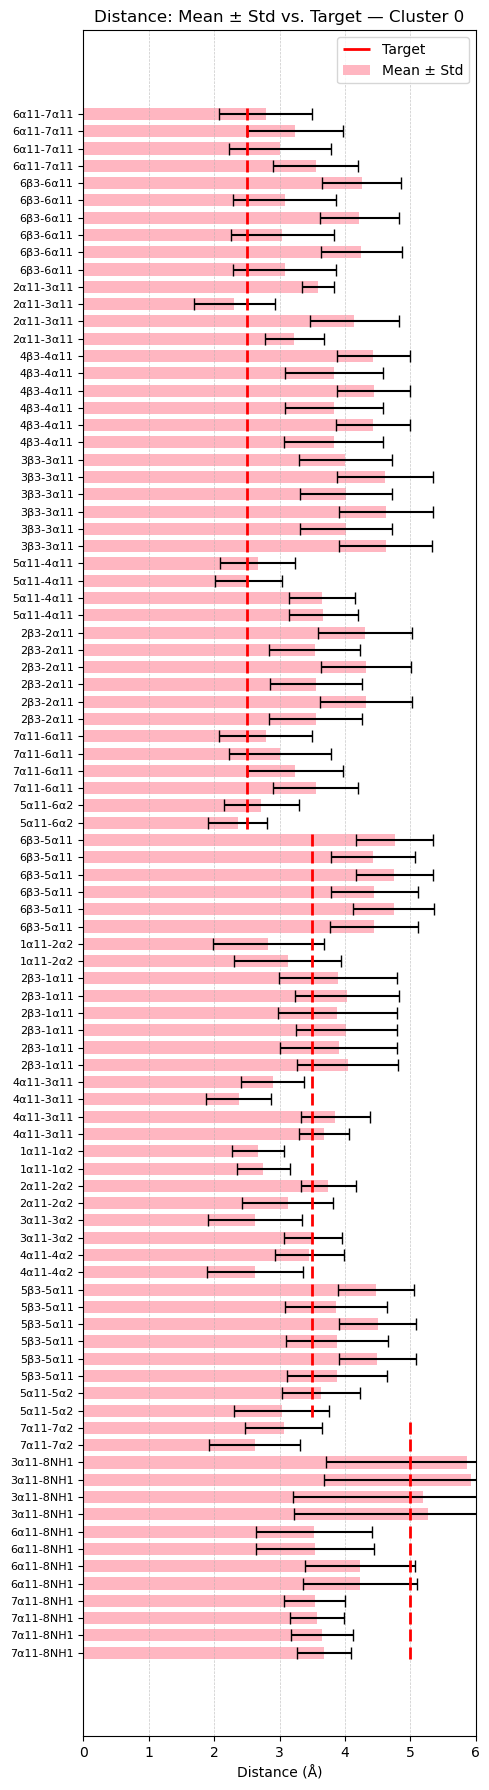

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

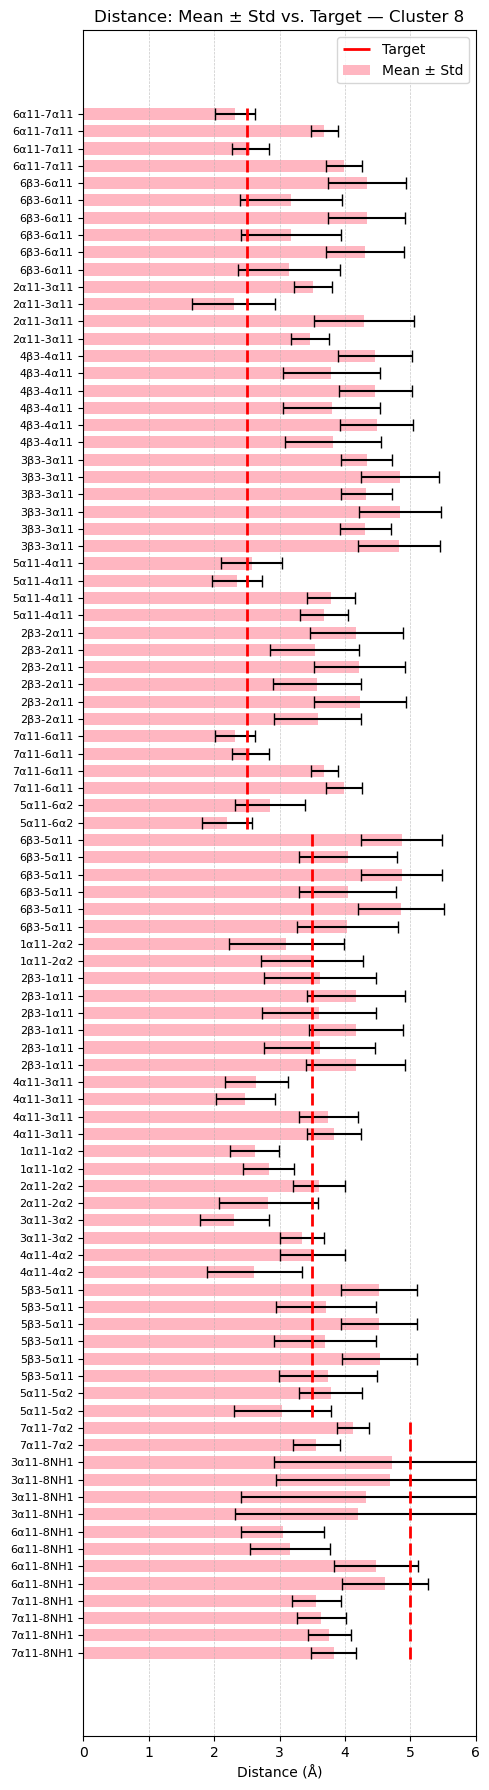

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

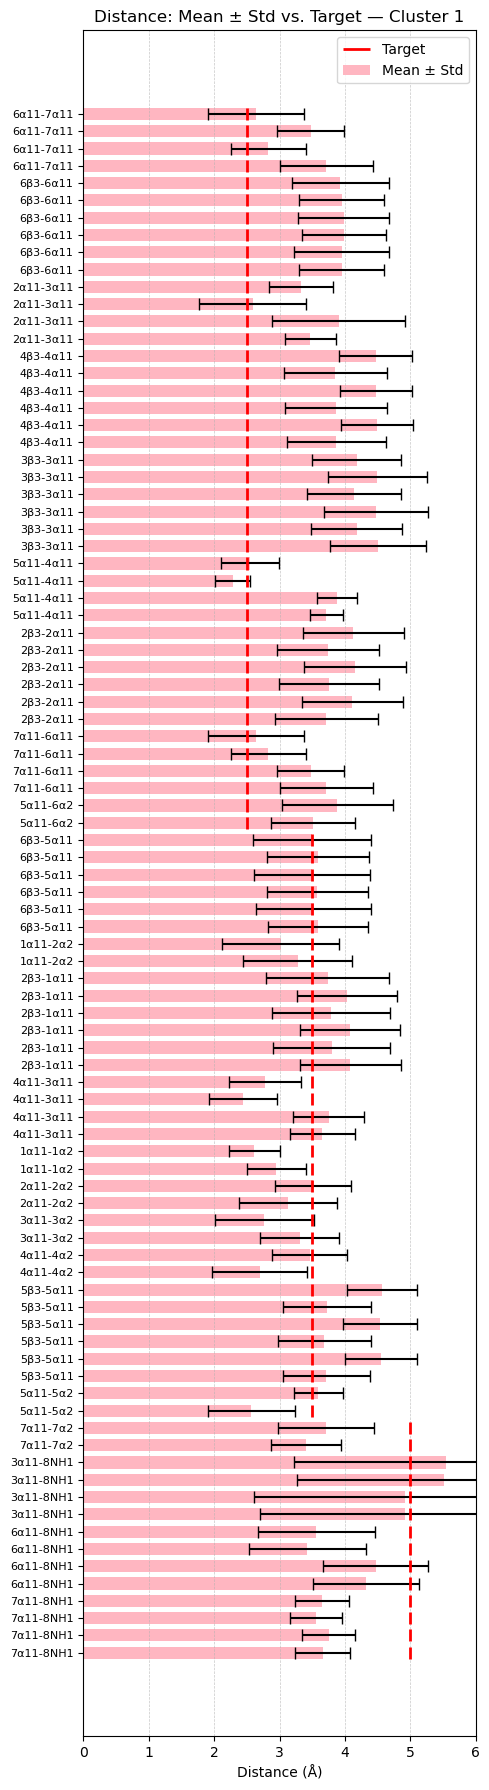

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

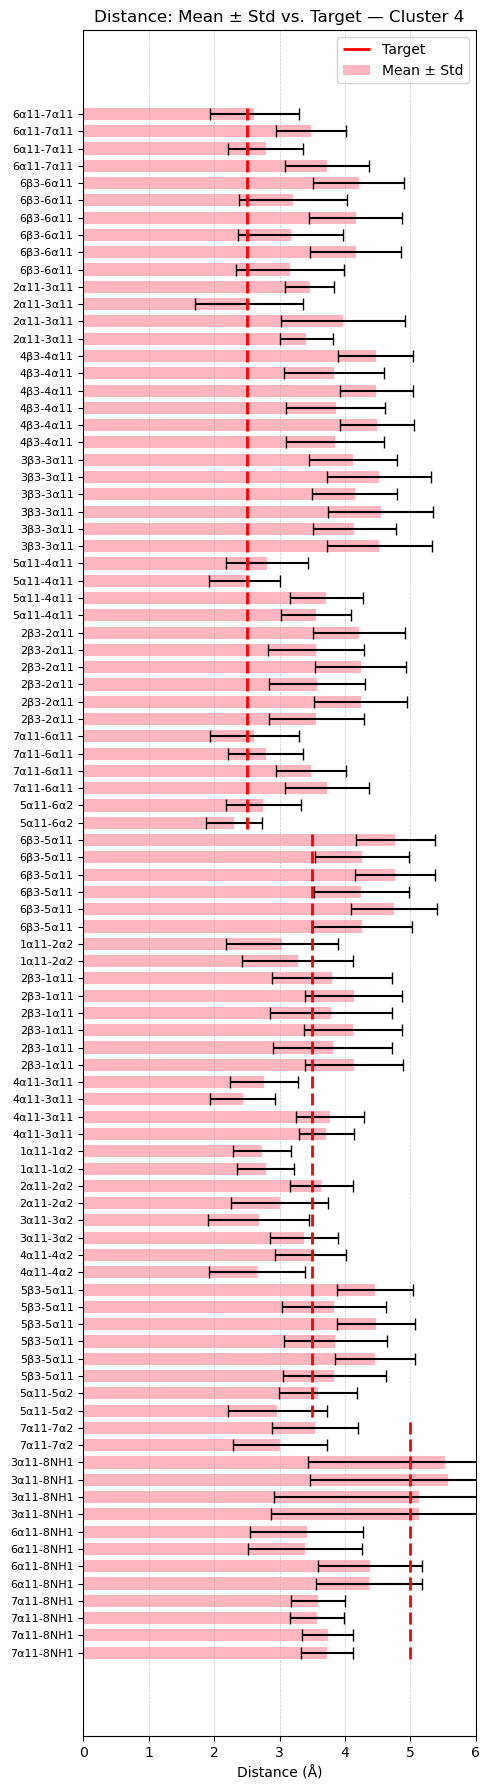

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

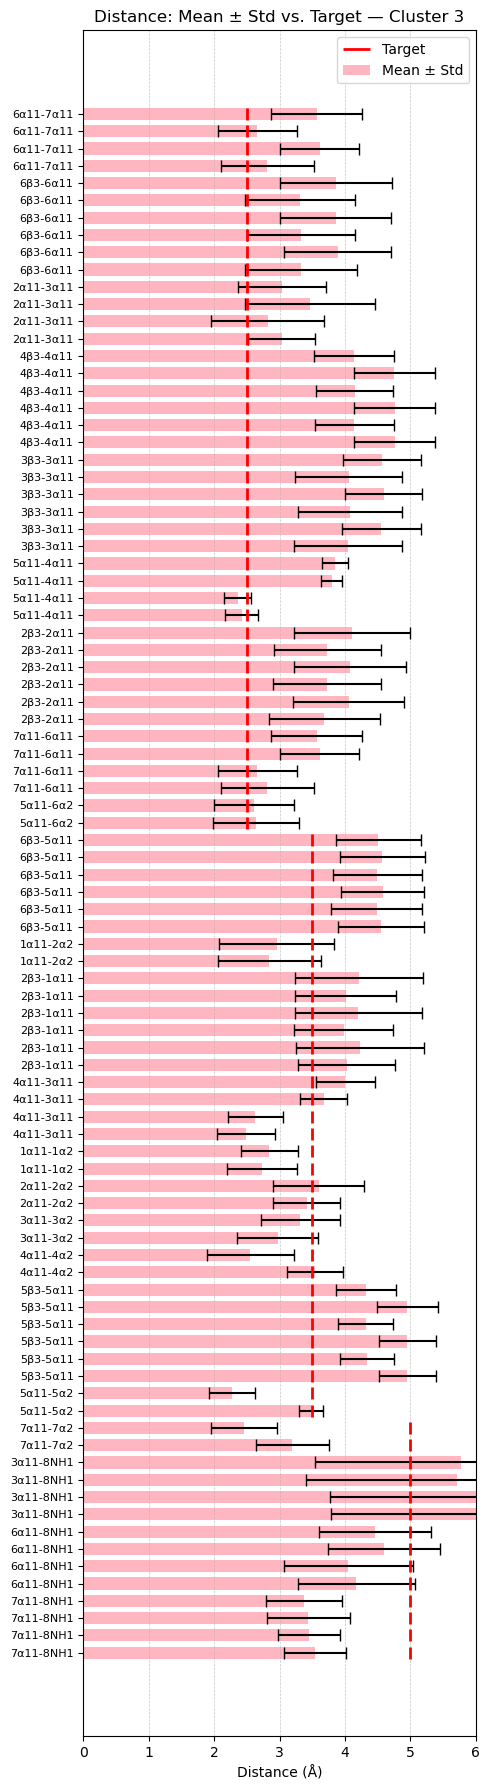

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

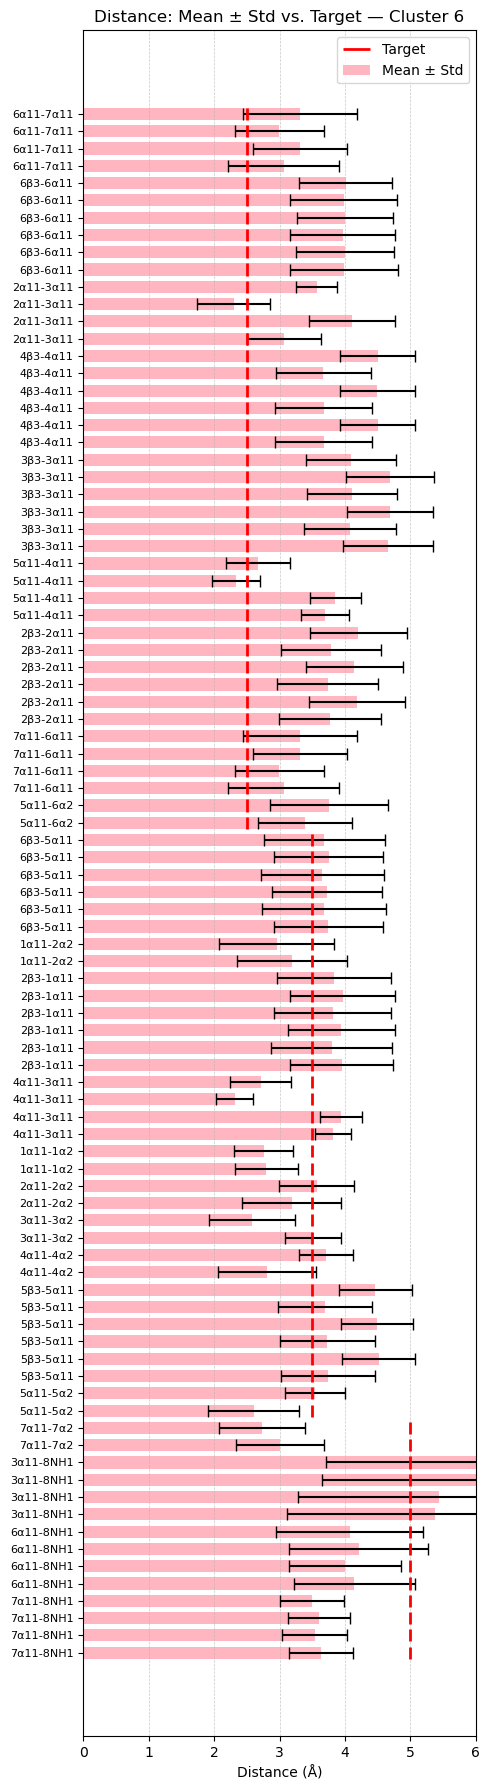

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

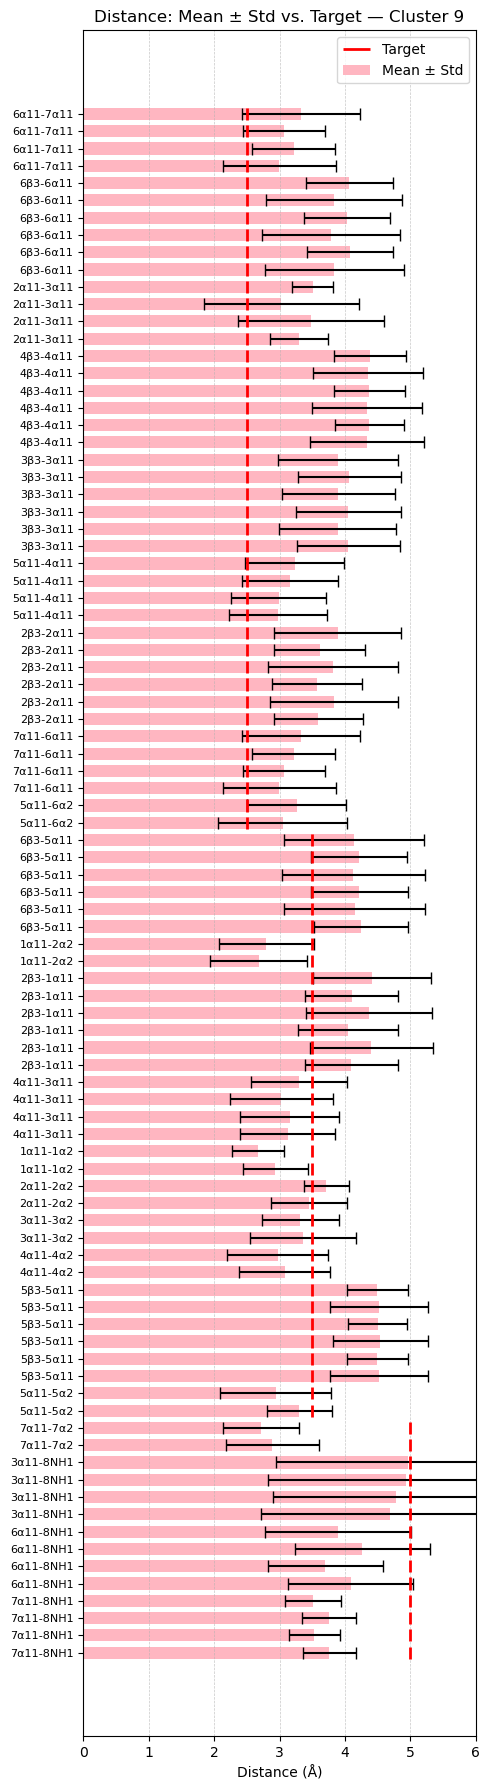

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

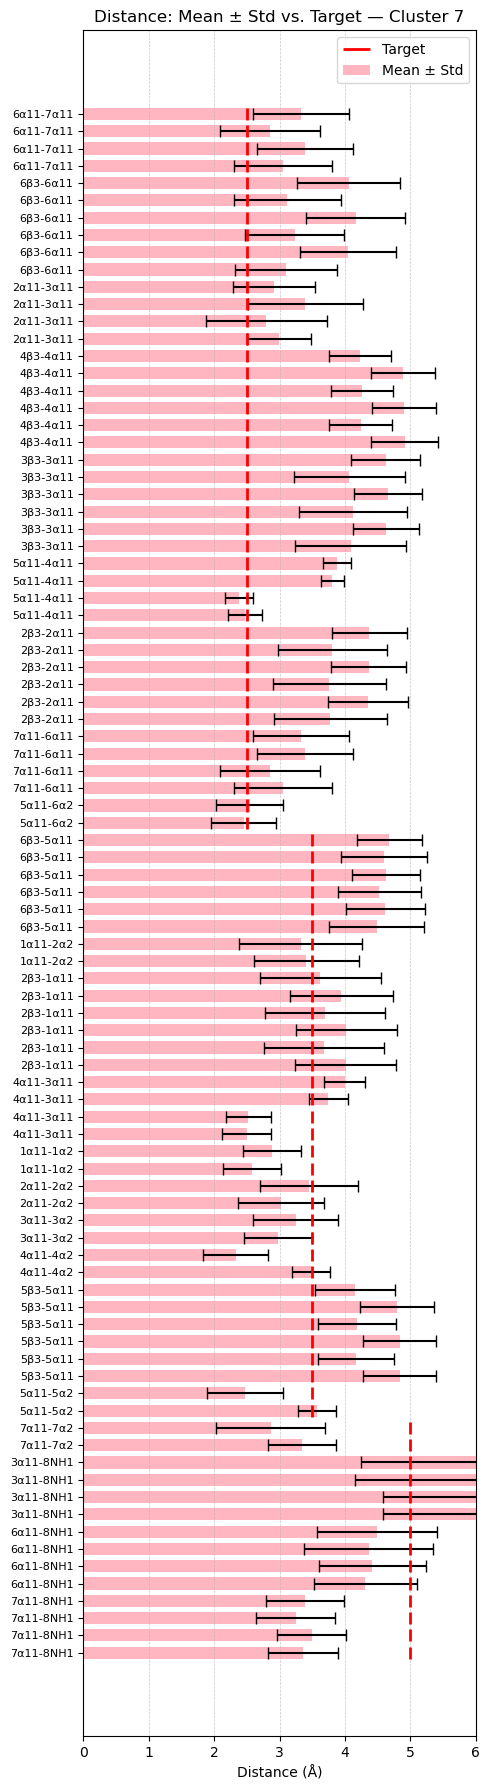

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

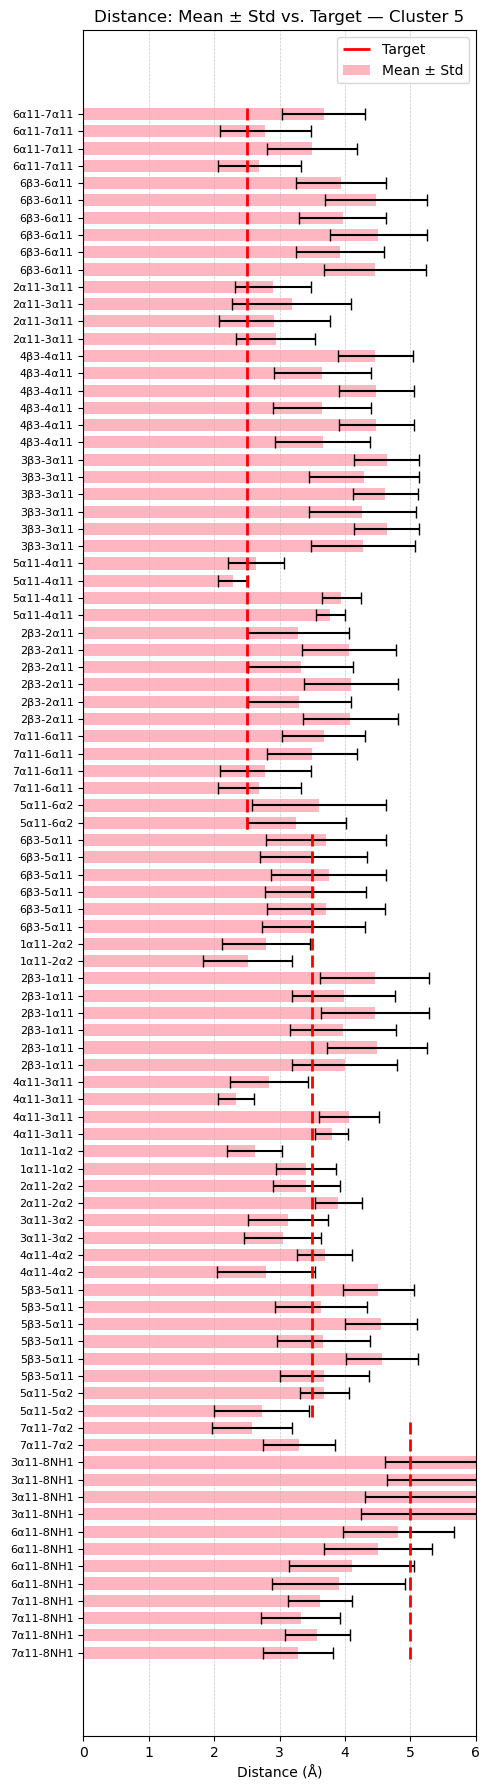

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

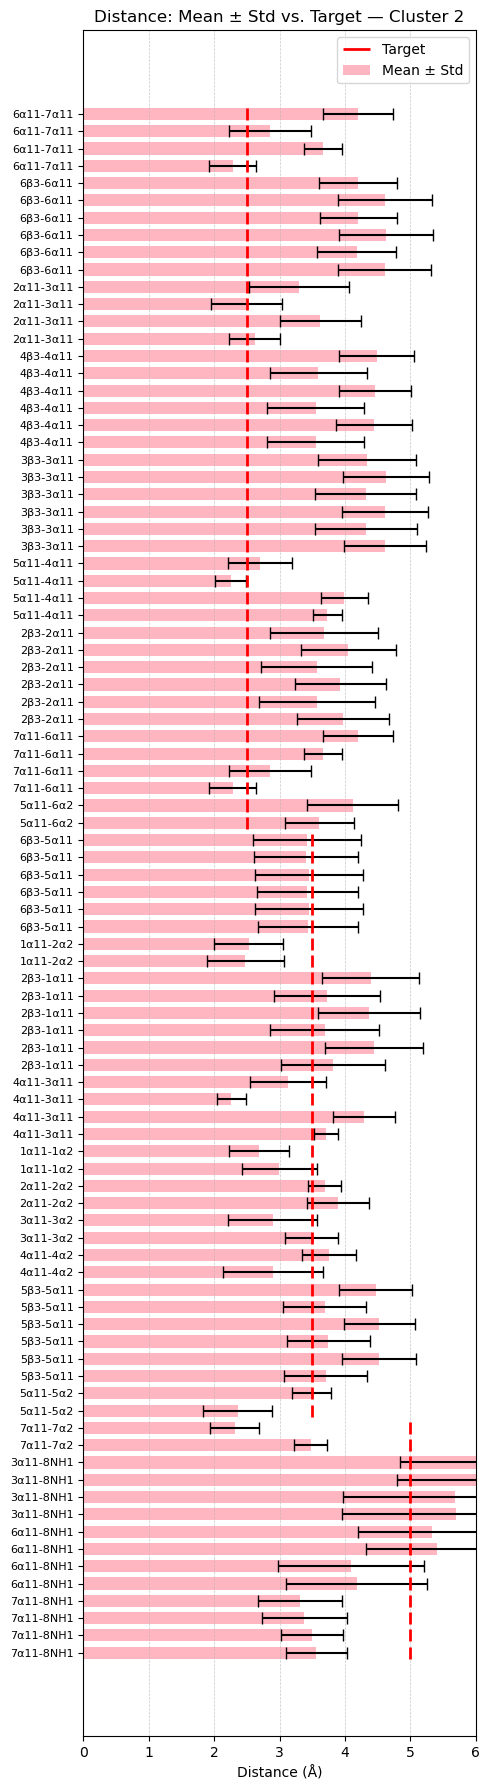

In [35]:
human_interpretable_label = True

grofile = f"../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"

# Loop over top clusters instead of state numbers
for cluster_label, frame_indices in top_cluster_data.items():
    means = []
    stds = []
    targets = []
    labels = []

    # Only use the first 90 columns (distance features)
    cluster_feat = feat_all[frame_indices]
    dist_feat = cluster_feat[:, :90]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]

        mean_val = np.mean(dist)
        std_val = np.std(dist)

        means.append(mean_val)
        stds.append(std_val)
        targets.append(target)

        # PyEMMA labels
        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            labels.append(translate_pyemma_label(label=label))
        else:
            labels.append(label)

    # Convert to numpy arrays
    means = np.array(means)
    stds = np.array(stds)
    targets = np.array(targets)

    y = np.arange(len(labels))
    height = 0.7

    plt.figure(figsize=(5, max(6, len(labels) * 0.2)))

    # Plot bars: mean ± std
    plt.barh(y, means, height=height, xerr=stds, capsize=4, label='Mean ± Std', color='lightpink')

    # Target distances
    target_label_plotted = False
    for yi, ti in zip(y, targets):
        if not target_label_plotted:
            plt.vlines(ti, yi - height / 2, yi + height / 2, colors='red', linestyles='-', linewidth=2, label='Target')
            target_label_plotted = True
        else:
            plt.vlines(ti, yi - height / 2, yi + height / 2, colors='red', linestyles='-', linewidth=2)

    plt.yticks(y, labels, fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Distance: Mean ± Std vs. Target — Cluster {cluster_label}")
    #plt.xlim(0, max(np.max(means + stds), np.max(targets)) * 1.1)
    plt.xlim(0, 6)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


### Analysis Dihedral

In [36]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_2 — State {state_idx} REMD (Distances Restrainted OFF)', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 12979 frames


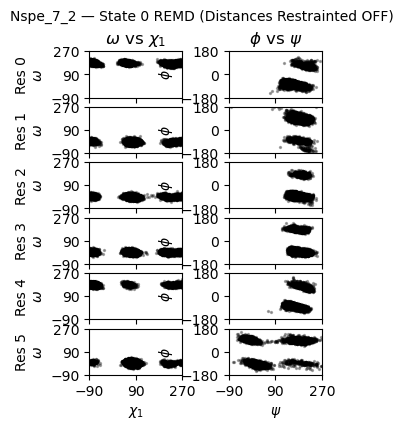

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 10599 frames


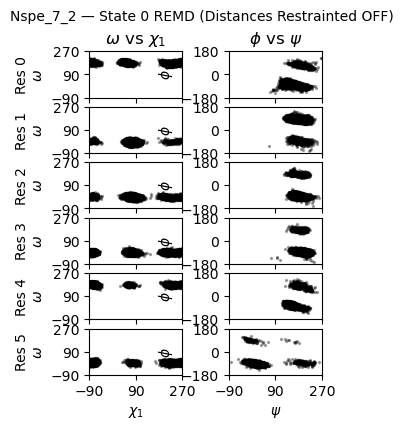

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 7471 frames


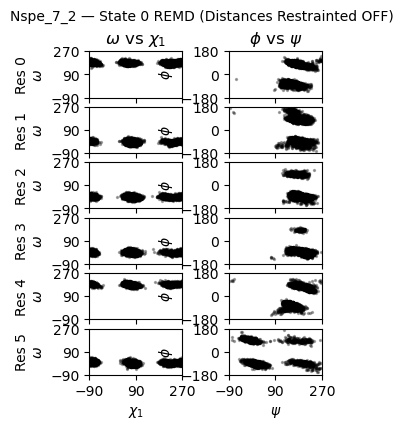

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 7324 frames


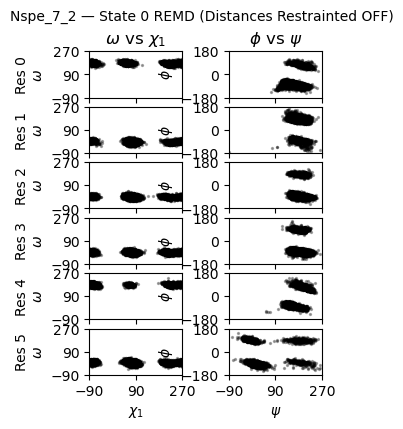

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 7117 frames


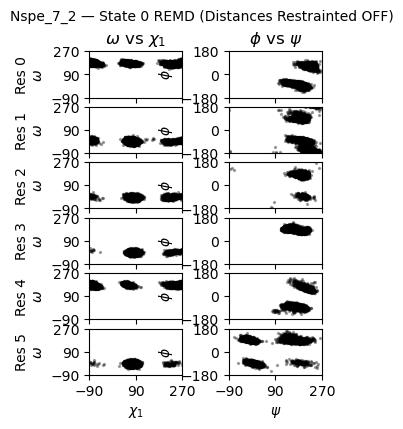

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 5948 frames


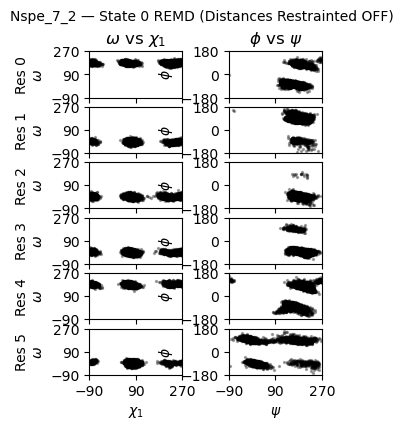

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 5911 frames


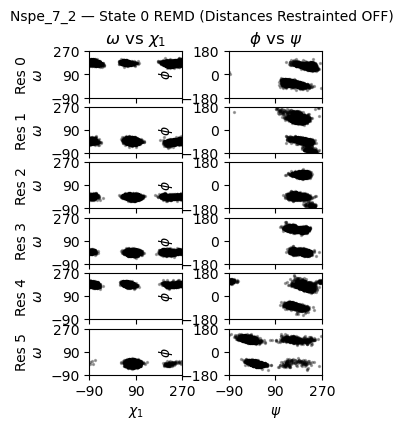

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 3815 frames


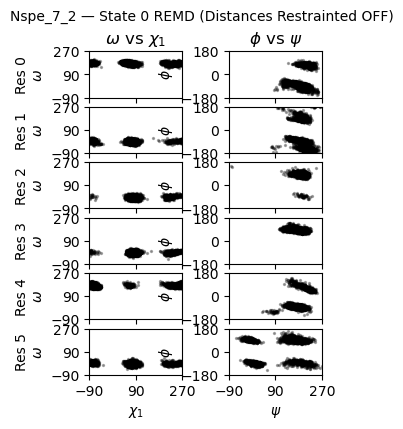

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 3067 frames


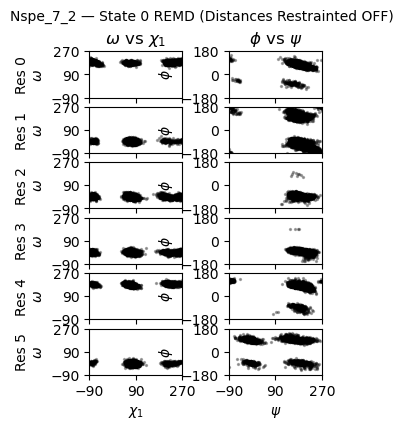

Plotting Cluster DIST: R02 6 H11 137 - R02 7 H11 160 with 2987 frames


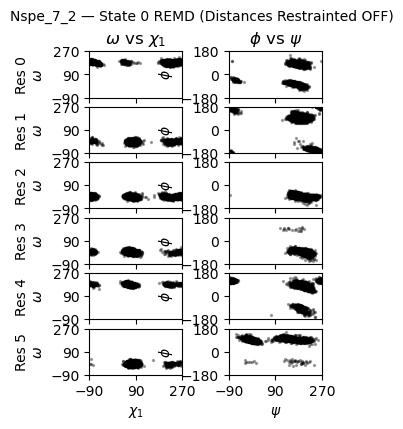

In [37]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for cluster_label, frame_indices in top_cluster_data.items():
    cluster_feat = feat_all[frame_indices]          # Now actual data
    omega_cluster = cluster_feat[:, -24:]     # Last 24 are omega etc.
    omega_input = omega_cluster[np.newaxis, :, :]  # Shape (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {omega_cluster.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Sampling

In [38]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [39]:
sample_size = 5

# Step 0: filtered_indices gives original row IDs from feat_all
# assignments was computed from filtered_omega_feat = feat_all[mask]

filtered_indices = np.where(mask)[0]  # <-- from earlier
selected_clusters = [label for label in np.unique(assignments) if label in top_labels]

cluster = {label: [] for label in selected_clusters}
frames = {label: [] for label in selected_clusters}

# Step 1: Map filtered indices (cluster assignments) to original frame IDs
for filtered_idx, assignment in enumerate(assignments):
    if assignment in selected_clusters:
        original_idx = filtered_indices[filtered_idx]
        cluster[assignment].append(original_idx)

# Step 2: Sample frame indices from each cluster
for label in selected_clusters:
    if len(cluster[label]) > 0:
        sample_n = min(sample_size, len(cluster[label]))
        indices = np.random.choice(cluster[label], size=sample_n, replace=False)
        frames[label] = indices.tolist()

print('Sampled frames per selected cluster:', {k: len(v) for k, v in frames.items()})

Sampled frames per selected cluster: {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 8: 5, 9: 5}


In [40]:

HREX_dir = '../traj_remd'
run_num = 5 # How many run

trajs = []
HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"  
    xtcfile = f"{HREX_path}/state_0/HREMD.part0001_intact.xtc"
    grofile = f"../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"
    traj = md.load(xtcfile, top=grofile)
    trajs.append(traj)

# Concatenate trajectories
concatenated_trajs = md.join(trajs)

# Save sampled frames to new xtc files
for cluster in frames:
    sampling = concatenated_trajs[frames[cluster]]    
    sampling.save_xtc(f"sampling/sample_state_0_cluster{cluster}.xtc")
    sampling.save_pdb(f"sampling/sample_state_0_cluster{cluster}.pdb")


## Visualized the sampled data

In [37]:
def get_sampled_data(cluster_id, feat_all, frames, dist_dim=90, dihedral_dim=24):
    indices = frames.get(cluster_id, [])
    if not indices:
        print(f"No sampled frames for cluster {cluster_id}.")
        return None, None, None
    feat = feat_all[indices]
    return feat, feat[:, :dist_dim], feat[:, -dihedral_dim:]

In [40]:
cluster_id = 135  # or any cluster you sampled


feat_sampled, dist_sampled, omega_sampled = get_sampled_data(cluster_id, feat_all, frames)


Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

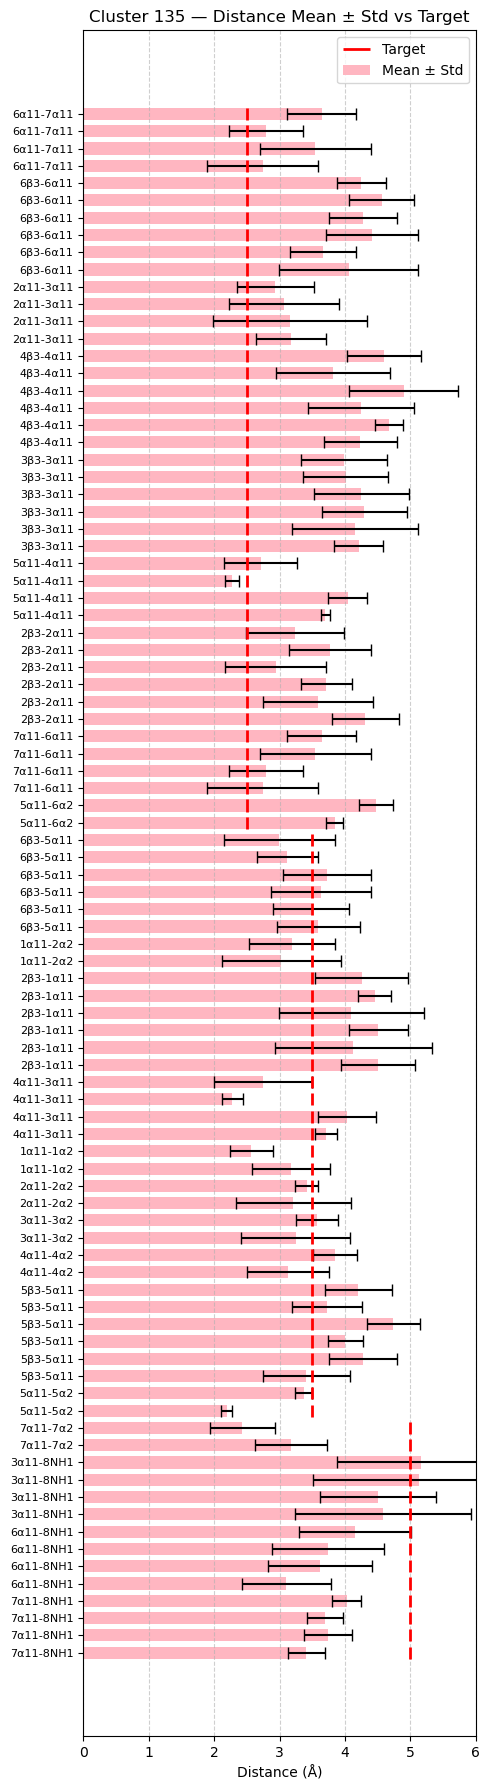

In [41]:
means = []
stds = []
targets = []
labels = []

for i, (atom1, atom2, target) in enumerate(dist_res):
    dist = dist_sampled[:, i]

    means.append(np.mean(dist))
    stds.append(np.std(dist))
    targets.append(target)

    atom1_pyemma = atom1 - 1
    atom2_pyemma = atom2 - 1
    feat = pyemma.coordinates.featurizer(grofile)
    feat.add_distances([[atom1_pyemma, atom2_pyemma]])
    label = feat.describe()[0]

    if human_interpretable_label:
        labels.append(translate_pyemma_label(label))
    else:
        labels.append(label)

# Plot bar graph
y = np.arange(len(labels))
height = 0.7
plt.figure(figsize=(5, max(6, len(labels) * 0.2)))
plt.barh(y, means, height=height, xerr=stds, capsize=4, color='lightpink', label='Mean ± Std')
for yi, ti in zip(y, targets):
    plt.vlines(ti, yi - height/2, yi + height/2, colors='red', linewidth=2, label='Target' if yi==0 else "")
plt.yticks(y, labels, fontsize=8)
plt.xlabel("Distance (Å)")
plt.title(f"Cluster {cluster_id} — Distance Mean ± Std vs Target")
plt.xlim(0, 6)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


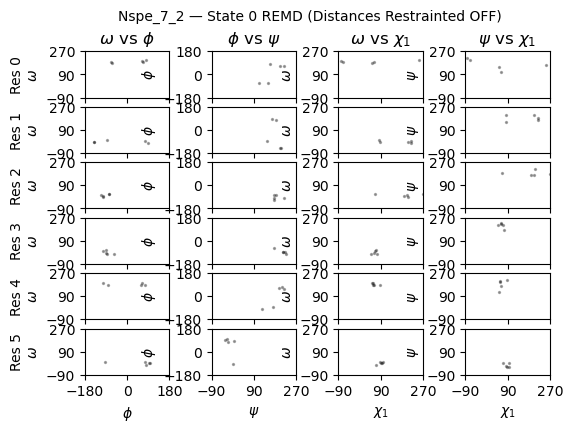

In [42]:
# Residue indices (each block is [omega, phi, psi, chi1])
residues_to_plot = [0, 4, 8, 12, 16, 20]

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

# Wrap angles into [-90, 270] if needed
for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omega_sampled[:, angle_indices] = (omega_sampled[:, angle_indices] + 90.0) % 360.0 - 90.0

# Prepare shape (1, n_sampled, 24) for plotting
omega_input = omega_sampled[np.newaxis, :, :]

# Plot
plot_dihedral_quadruplets(
    omega_all=omega_input,
    residues_to_plot=residues_to_plot,
    states=[0],  # Only 1 state (sampled cluster)
    use_latex=True,
    angles_to_plot=["omega_phi", "phi_psi", "omega_chi1", "psi_chi1"]
)
